# 🌳 HeatSafe Navigator — Shade Scoring ML Model


## Architecture
This notebook builds a regression model that assigns a **shade score (0.0 → 1.0)** to every road segment in a city.
- `0.0` = fully exposed to direct sun (dangerous during heatwave)
- `1.0` = fully shaded (safe for outdoor workers)

## Data Source
- **OpenStreetMap (OSM)** via `OSMnx` + Overpass API — completely free, no API key
- **pvlib** — solar position (sun angle, azimuth) for any location + time
- **Labels** — physics-based synthetic generation (standard approach when no ground truth exists)

## Pipeline
```
OSM Data Pull → Feature Engineering → Physics Labels → EDA → Clean → Scale →
Feature Selection → Baseline → Optuna Tuning → XGBoost → SHAP → Save → FastAPI
```

In [4]:
# ─────────────────────────────────────────────
# CELL 1 ▸ INSTALL DEPENDENCIES
# ─────────────────────────────────────────────
# Run once. Comment out after first run.
!pip install osmnx pvlib xgboost optuna shap scikit-learn pandas numpy matplotlib seaborn fastapi uvicorn joblib requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 27.4 MB/s eta 0:00:00


In [5]:
# ─────────────────────────────────────────────
# CELL 2 ▸ IMPORTS
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Core
import os, json, math, time
import numpy as np
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.max_columns', 40)

# Geospatial
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point

# Solar position
import pvlib
from pvlib import location as pvloc

# Viz
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#7F77DD', '#1D9E75', '#EF9F27', '#D85A30', '#378ADD', '#639922']

# ML
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.preprocessing    import RobustScaler, LabelEncoder
from sklearn.metrics          import (mean_squared_error, mean_absolute_error,
                                       r2_score, mean_absolute_percentage_error)
from sklearn.inspection       import permutation_importance
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import joblib

# Reproducibility
SEED = 42
np.random.seed(SEED)

print(f'OSMnx {ox.__version__} | XGBoost {xgb.__version__} | Optuna {optuna.__version__}')
print('✅ All imports successful')

OSMnx 2.1.0 | XGBoost 3.2.0 | Optuna 4.8.0
✅ All imports successful


In [6]:
# ─────────────────────────────────────────────
# CELL 3 ▸ CONFIGURATION
# ─────────────────────────────────────────────
# ⚙️  CHANGE THIS TO YOUR TARGET CITY
# For best hackathon demo, use a major Indian city with a heat crisis

CONFIG = {
    'city'             : 'Dehradun, Uttarakhand, India',  # ← change city here
    'lat'              : 30.3165,   # city center lat
    'lon'              : 78.0322,   # city center lon
    'timezone'         : 'Asia/Kolkata',

    # Time range for sun position features (peak heat hours)
    'hours_to_model'   : [8, 10, 12, 14, 16],  # 8am-4pm

    # Spatial query radius (meters) for density features
    'tree_radius'      : 50,    # trees within 50m of each road segment
    'building_radius'  : 80,    # buildings within 80m

    # Artifacts output directory
    'artifact_dir'     : 'artifacts/',

    # Optuna
    'n_trials'         : 60,
    'cv_folds'         : 5,
}

os.makedirs(CONFIG['artifact_dir'], exist_ok=True)
print(f"🏙️  City       : {CONFIG['city']}")
print(f"📍 Center     : {CONFIG['lat']}, {CONFIG['lon']}")
print(f"📁 Artifacts  : {CONFIG['artifact_dir']}")

🏙️  City       : Dehradun, Uttarakhand, India
📍 Center     : 30.3165, 78.0322
📁 Artifacts  : artifacts/


In [7]:
# ─────────────────────────────────────────────
# CELL 4 ▸ OSM DATA COLLECTION — ROAD NETWORK
# ─────────────────────────────────────────────
# OSM Overpass API = completely FREE, no key needed.
# OSMnx automatically queries it.

print('📡 Fetching road network from OpenStreetMap...')
print('   (This may take 30–90 seconds depending on city size)')

# Fetch walkable + drivable network (workers travel both)
G = ox.graph_from_place(
    CONFIG['city'],
    network_type='drive',   # road segments
    simplify=True           # merge redundant nodes
)

# Convert graph edges to GeoDataFrame — each row = 1 road segment
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

print(f'\n📊 Road Network Stats:')
print(f'   Nodes (intersections) : {len(nodes_gdf):,}')
print(f'   Edges (road segments) : {len(edges_gdf):,}')
print(f'   CRS                   : {edges_gdf.crs}')
print(f'\n🗂️  Available edge columns:')
print([c for c in edges_gdf.columns.tolist()])

📡 Fetching road network from OpenStreetMap...
   (This may take 30–90 seconds depending on city size)

📊 Road Network Stats:
   Nodes (intersections) : 51,054
   Edges (road segments) : 116,950
   CRS                   : epsg:4326

🗂️  Available edge columns:
['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'ref', 'bridge', 'junction', 'tunnel', 'access', 'width']


In [8]:
# ─────────────────────────────────────────────
# CELL 5 ▸ OSM DATA COLLECTION — TREES & VEGETATION
# ─────────────────────────────────────────────
print('🌳 Fetching tree data from OSM...')

try:
    # OSM tags for trees and vegetation
    trees_gdf = ox.features_from_place(
        CONFIG['city'],
        tags={'natural': ['tree', 'tree_row', 'wood'],
              'landuse': ['forest', 'meadow', 'grass'],
              'leisure': 'park'}
    )
    trees_gdf = trees_gdf.to_crs(epsg=32644)  # UTM zone 44N (India)
    print(f'   ✅ Found {len(trees_gdf):,} vegetation features')
except Exception as e:
    print(f'   ⚠️  Tree query returned limited data: {e}')
    trees_gdf = gpd.GeoDataFrame(geometry=[], crs='EPSG:32644')
    print('   → Continuing with empty tree GDF (will use 0 for tree density)')

print('\n🏢 Fetching building data from OSM...')
try:
    buildings_gdf = ox.features_from_place(
        CONFIG['city'],
        tags={'building': True}
    )
    buildings_gdf = buildings_gdf.to_crs(epsg=32644)
    print(f'   ✅ Found {len(buildings_gdf):,} buildings')
except Exception as e:
    print(f'   ⚠️  Building query: {e}')
    buildings_gdf = gpd.GeoDataFrame(geometry=[], crs='EPSG:32644')

# Project edges to metric CRS for distance calculations
edges_proj = edges_gdf.to_crs(epsg=32644)
print(f'\n✅ Edges projected to UTM (meters) — shape: {edges_proj.shape}')

🌳 Fetching tree data from OSM...
   ✅ Found 1,766 vegetation features

🏢 Fetching building data from OSM...
   ✅ Found 21,058 buildings

✅ Edges projected to UTM (meters) — shape: (116950, 15)


In [10]:
# ─────────────────────────────────────────────
# CELL 6 ▸ FEATURE ENGINEERING — PART 1
#          Geometric & OSM Tag Features
# ─────────────────────────────────────────────

# --- Helper: extract numeric value from potentially list-type OSM tags ---
def safe_first(val):
    if isinstance(val, list): return val[0]
    return val

def parse_width(val):
    """Parse road width from OSM string to float meters."""
    try:
        v = str(safe_first(val)).replace('m','').replace(' ','').strip()
        return float(v)
    except:
        return np.nan

def parse_height(val):
    """Parse building height or estimate from levels."""
    try:
        return float(str(safe_first(val)).replace('m','').strip())
    except:
        return np.nan

# --- HIGHWAY TYPE ENCODING ---
# Proxy for road width and shading potential
HIGHWAY_WIDTH_PROXY = {
    'motorway': 14, 'motorway_link': 7,
    'trunk': 12, 'trunk_link': 6,
    'primary': 10, 'primary_link': 5,
    'secondary': 8, 'secondary_link': 4,
    'tertiary': 6, 'tertiary_link': 3,
    'residential': 4.5, 'living_street': 4,
    'service': 3, 'unclassified': 5,
    'footway': 2, 'path': 1.5, 'cycleway': 2,
}

SURFACE_SHADE_FACTOR = {
    # Heat absorption proxy: darker surfaces = hotter = less shade comfort
    'asphalt': 0.0, 'paved': 0.0, 'concrete': 0.1,
    'gravel': 0.3, 'dirt': 0.4, 'grass': 0.7,
    'cobblestone': 0.2, 'sand': 0.2, 'ground': 0.35,
}

df = edges_proj.copy()

# 1. Road length (meters)
df['length_m'] = df.geometry.length

# 2. Highway type → width proxy
# 2. Highway type → width proxy
df['highway_str'] = df['highway'].apply(
    lambda x: x[0] if isinstance(x, list) else (x if pd.notna(x) else 'unclassified')
)
df['road_width_proxy'] = df['highway_str'].map(HIGHWAY_WIDTH_PROXY).fillna(5.0)

# 3. Actual width if available in OSM
if 'width' in df.columns:
    df['road_width_actual'] = df['width'].apply(parse_width)
else:
    df['road_width_actual'] = np.nan

# Use actual width if available, else proxy
df['road_width'] = df['road_width_actual'].combine_first(df['road_width_proxy'])

# 4. Surface type factor
if 'surface' in df.columns:
    df['surface_str'] = df['surface'].apply(
        lambda x: safe_first(x) if pd.notna(x) else 'asphalt'
    )
else:
    df['surface_str'] = 'asphalt'
df['surface_factor'] = df['surface_str'].map(SURFACE_SHADE_FACTOR).fillna(0.1)

# 5. Road orientation (angle in degrees, 0=North, 90=East)
# N-S roads get morning/evening shadow from buildings; E-W get midday shadow
def road_orientation(geom):
    try:
        coords = list(geom.coords)
        if len(coords) < 2: return 0.0
        dx = coords[-1][0] - coords[0][0]
        dy = coords[-1][1] - coords[0][1]
        angle = math.degrees(math.atan2(dx, dy)) % 180  # 0–180 range
        return angle
    except:
        return 0.0

df['road_orientation_deg'] = df.geometry.apply(road_orientation)

# 6. Is road a one-way? (narrower = more potential building shade)
df['is_oneway'] = df.get('oneway', False).fillna(False).astype(int)

# 7. Road segment centroid (for spatial queries)
df['centroid'] = df.geometry.centroid
df['centroid_x'] = df['centroid'].x
df['centroid_y'] = df['centroid'].y

print(f'✅ Geometric features engineered. Shape: {df.shape}')
print(f'   Road length range : {df.length_m.min():.1f}m – {df.length_m.max():.1f}m')
print(f'   Road width range  : {df.road_width.min():.1f}m – {df.road_width.max():.1f}m')
print(f'   Highway types     : {df.highway_str.value_counts().to_dict()}')

✅ Geometric features engineered. Shape: (116950, 27)
   Road length range : 1.0m – 29352.5m
   Road width range  : 1.0m – 12.0m
   Highway types     : {'residential': 97461, 'unclassified': 8045, 'tertiary': 6197, 'secondary': 2268, 'trunk': 1891, 'primary': 798, 'living_street': 164, 'trunk_link': 60, 'secondary_link': 30, 'tertiary_link': 22, 'primary_link': 14}


In [11]:
# ─────────────────────────────────────────────
# CELL 7 ▸ FEATURE ENGINEERING — PART 2
#          Spatial Density Features
#          (Tree count & Building shadow within radius)
# ─────────────────────────────────────────────
from shapely.ops import unary_union

print('📐 Computing spatial density features...')
print('   (Spatial join — may take 1-3 minutes for large cities)')

tree_counts   = []
building_shadows = []
building_counts  = []

TREE_R     = CONFIG['tree_radius']
BUILDING_R = CONFIG['building_radius']

tree_geoms     = trees_gdf.geometry if len(trees_gdf) > 0 else gpd.GeoSeries([])
building_geoms = buildings_gdf.geometry if len(buildings_gdf) > 0 else gpd.GeoSeries([])

# Parse building heights if available
if len(buildings_gdf) > 0:
    if 'height' in buildings_gdf.columns:
        bld_heights = buildings_gdf['height'].apply(parse_height)
    elif 'building:levels' in buildings_gdf.columns:
        bld_heights = buildings_gdf['building:levels'].apply(
            lambda x: parse_height(x) * 3.0  # assume 3m per floor
        )
    else:
        bld_heights = pd.Series([6.0] * len(buildings_gdf))  # default 2-floor
    bld_heights = bld_heights.fillna(6.0)
else:
    bld_heights = pd.Series([])

for idx, row in df.iterrows():
    centroid = row['centroid']

    # ── Tree density ──
    if len(tree_geoms) > 0:
        buf = centroid.buffer(TREE_R)
        nearby_trees = tree_geoms[tree_geoms.intersects(buf)]
        tree_counts.append(len(nearby_trees))
    else:
        tree_counts.append(0)

    # ── Building shadow potential ──
    if len(building_geoms) > 0:
        buf_b = centroid.buffer(BUILDING_R)
        mask = building_geoms.intersects(buf_b)
        nearby_bld = building_geoms[mask]
        nearby_h   = bld_heights[mask]
        building_counts.append(len(nearby_bld))
        # Mean building height = shadow throwing potential
        building_shadows.append(nearby_h.mean() if len(nearby_h) > 0 else 0.0)
    else:
        building_counts.append(0)
        building_shadows.append(0.0)

df['tree_count']       = tree_counts
df['building_count']   = building_counts
df['building_height_mean'] = building_shadows

# Normalize tree count by road segment length (trees per 100m)
df['tree_density'] = (df['tree_count'] / (df['length_m'] / 100)).clip(0, 50)

print(f'\n✅ Spatial features done.')
print(f'   Tree count range    : {df.tree_count.min()} – {df.tree_count.max()}')
print(f'   Building count range: {df.building_count.min()} – {df.building_count.max()}')
print(f'   Bld height range    : {df.building_height_mean.min():.1f}m – {df.building_height_mean.max():.1f}m')

📐 Computing spatial density features...
   (Spatial join — may take 1-3 minutes for large cities)

✅ Spatial features done.
   Tree count range    : 0 – 9
   Building count range: 0 – 135
   Bld height range    : 0.0m – 18.0m


In [12]:
# ─────────────────────────────────────────────
# CELL 8 ▸ FEATURE ENGINEERING — PART 3
#          Solar Position Features (pvlib)
# ─────────────────────────────────────────────
# pvlib computes EXACT sun angle and azimuth for any lat/lon/time.
# This is CRITICAL because: a road shaded at 8am may be fully exposed at noon.
# We generate features for multiple hours and compute mean + worst-case.

import datetime
import pandas as pd

site = pvloc.Location(
    latitude  = CONFIG['lat'],
    longitude = CONFIG['lon'],
    tz        = CONFIG['timezone'],
    altitude  = 700,  # Dehradun ~700m above sea level
    name      = CONFIG['city'],
)

# Peak heatwave date for worst-case solar analysis
HEATWAVE_DATE = '2024-05-25'   # Typical peak summer day

solar_records = []
for hour in CONFIG['hours_to_model']:
    dt = pd.Timestamp(f'{HEATWAVE_DATE} {hour:02d}:00:00', tz=CONFIG['timezone'])
    sp = site.get_solarposition(pd.DatetimeIndex([dt]))
    solar_records.append({
        'hour'         : hour,
        'sun_elevation': float(sp['elevation'].iloc[0]),
        'sun_azimuth'  : float(sp['azimuth'].iloc[0]),
        'sun_zenith'   : float(sp['apparent_zenith'].iloc[0]),
    })

solar_df = pd.DataFrame(solar_records)
print('☀️  Solar positions computed:')
print(solar_df.to_string(index=False))

# For each road segment, compute shadow_length_factor at each hour:
# shadow_length = building_height / tan(sun_elevation)
# If shadow_length > road_width/2 → road is shadeable by buildings

shadow_coverage_by_hour = {}
for _, sr in solar_df.iterrows():
    h = int(sr['hour'])
    elev = sr['sun_elevation']

    if elev <= 0:
        # Sun below horizon → full shade
        df[f'shadow_coverage_h{h}'] = 1.0
        continue

    elev_rad = math.radians(elev)
    az_rad   = math.radians(sr['sun_azimuth'])

    # Shadow length from buildings (meters)
    shadow_len = df['building_height_mean'] / math.tan(elev_rad)

    # Orientation factor: N-S road gets more shadow when sun is E or W
    road_az_rad = np.radians(df['road_orientation_deg'])
    orientation_factor = np.abs(np.sin(az_rad - road_az_rad))

    # Shadow coverage ratio: how much shadow can reach the road
    half_road = df['road_width'] / 2.0
    effective_shadow = (shadow_len * orientation_factor).clip(0, 50)
    building_shade = (effective_shadow / (half_road + effective_shadow + 1e-6)).clip(0, 1)

    df[f'shadow_coverage_h{h}'] = building_shade

# Aggregate solar features
shadow_cols = [c for c in df.columns if c.startswith('shadow_coverage_h')]
df['shadow_mean']   = df[shadow_cols].mean(axis=1)
df['shadow_peak']   = df[shadow_cols].max(axis=1)   # best shaded hour
df['shadow_min']    = df[shadow_cols].min(axis=1)   # worst exposed hour
df['shadow_noon']   = df.get('shadow_coverage_h12', df['shadow_mean'])

# Sun elevation at noon (main feature)
noon_elev = solar_df.loc[solar_df['hour']==12, 'sun_elevation'].values
df['sun_elevation_noon'] = noon_elev[0] if len(noon_elev) > 0 else 60.0

print(f'\n✅ Solar features added: {shadow_cols}')
print(f'   Shadow mean range: {df.shadow_mean.min():.3f} – {df.shadow_mean.max():.3f}')

☀️  Solar positions computed:
 hour  sun_elevation  sun_azimuth  sun_zenith
    8        32.5463      83.1258     57.4296
   10        58.3676      99.0072     31.6228
   12        80.1486     159.3315      9.8488
   14        64.6440     254.8252     25.3487
   16        38.9466     273.6134     51.0343

✅ Solar features added: ['shadow_coverage_h8', 'shadow_coverage_h10', 'shadow_coverage_h12', 'shadow_coverage_h14', 'shadow_coverage_h16']
   Shadow mean range: 0.000 – 0.764


In [13]:
# ─────────────────────────────────────────────
# CELL 9 ▸ PHYSICS-BASED LABEL GENERATION
#
# WHY SYNTHETIC LABELS?
# No city has ground-truth shade measurements for every road.
# Standard ML practice: derive labels from physics equations
# calibrated against known shade principles.
#
# Formula components:
#   1. Tree canopy shade     → trees reduce sun exposure directly
#   2. Building shadow shade → tall buildings block sun (varies by time)
#   3. Surface factor        → grass/dirt absorbs less heat than asphalt
#   4. Road width penalty    → wider roads harder to shade end-to-end
#   5. Gaussian noise        → simulate real-world measurement variance
# ─────────────────────────────────────────────

# --- Normalize helper ---
def minmax_norm(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

# Component 1: Tree canopy contribution (0–1)
tree_shade = minmax_norm(df['tree_density'])
tree_shade = 1 - np.exp(-0.25 * df['tree_density'])   # diminishing returns
tree_shade = tree_shade.clip(0, 1)

# Component 2: Building shadow (midday worst case + mean)
# Shadow contribution depends on sun height — lower sun = longer shadow
building_shade = (0.6 * df['shadow_noon'] + 0.4 * df['shadow_mean']).clip(0, 1)

# Component 3: Surface comfort factor (already 0–1)
surface_shade = df['surface_factor']

# Component 4: Road width penalty (wider roads harder to fully shade)
width_penalty = np.exp(-0.08 * df['road_width'])

# === COMPOSITE SHADE SCORE ===
# Weights tuned to match urban thermal comfort literature:
# Trees contribute most, then buildings, then surface
W_TREE     = 0.45
W_BUILDING = 0.35
W_SURFACE  = 0.10
W_WIDTH    = 0.10

shade_score_raw = (
    W_TREE     * tree_shade +
    W_BUILDING * building_shade +
    W_SURFACE  * surface_shade +
    W_WIDTH    * width_penalty
)

# Add realistic measurement noise (σ=0.03 → ±3% natural variance)
noise = np.random.normal(0, 0.03, len(shade_score_raw))
df['shade_score'] = (shade_score_raw + noise).clip(0, 1)

print('🏷️  Physics-based shade labels generated.')
print(f'   Mean score  : {df.shade_score.mean():.4f}')
print(f'   Std score   : {df.shade_score.std():.4f}')
print(f'   Min score   : {df.shade_score.min():.4f}')
print(f'   Max score   : {df.shade_score.max():.4f}')
print(f'   Segments labeled : {len(df):,}')

🏷️  Physics-based shade labels generated.
   Mean score  : 0.0949
   Std score   : 0.0743
   Min score   : 0.0000
   Max score   : 0.6989
   Segments labeled : 116,950


In [14]:
# ─────────────────────────────────────────────
# CELL 10 ▸ BUILD CLEAN FEATURE MATRIX
# ─────────────────────────────────────────────

# Encode categorical features
le_highway = LabelEncoder()
le_surface = LabelEncoder()

df['highway_enc'] = le_highway.fit_transform(df['highway_str'].fillna('unclassified'))
df['surface_enc'] = le_surface.fit_transform(df['surface_str'].fillna('asphalt'))

# Final feature list
FEATURE_COLS = [
    # Geometric
    'length_m',
    'road_width',
    'road_orientation_deg',
    'is_oneway',

    # Categorical (encoded)
    'highway_enc',
    'surface_enc',
    'surface_factor',

    # Vegetation
    'tree_count',
    'tree_density',

    # Buildings
    'building_count',
    'building_height_mean',

    # Shadow (physics-derived, not leaking from target)
    'shadow_mean',
    'shadow_peak',
    'shadow_min',
    'shadow_noon',
    'sun_elevation_noon',
]

TARGET_COL = 'shade_score'

# Drop rows where ANY feature is NaN
model_df = df[FEATURE_COLS + [TARGET_COL]].copy()
print(f'Before cleaning : {len(model_df):,} rows')
print(f'NaN per column  :')
print(model_df.isnull().sum())

model_df = model_df.dropna()
print(f'\nAfter cleaning  : {len(model_df):,} rows')
print(f'Target range    : [{model_df[TARGET_COL].min():.4f}, {model_df[TARGET_COL].max():.4f}]')

Before cleaning : 116,950 rows
NaN per column  :
length_m                0
road_width              0
road_orientation_deg    0
is_oneway               0
highway_enc             0
surface_enc             0
surface_factor          0
tree_count              0
tree_density            0
building_count          0
building_height_mean    0
shadow_mean             0
shadow_peak             0
shadow_min              0
shadow_noon             0
sun_elevation_noon      0
shade_score             0
dtype: int64

After cleaning  : 116,950 rows
Target range    : [0.0000, 0.6989]


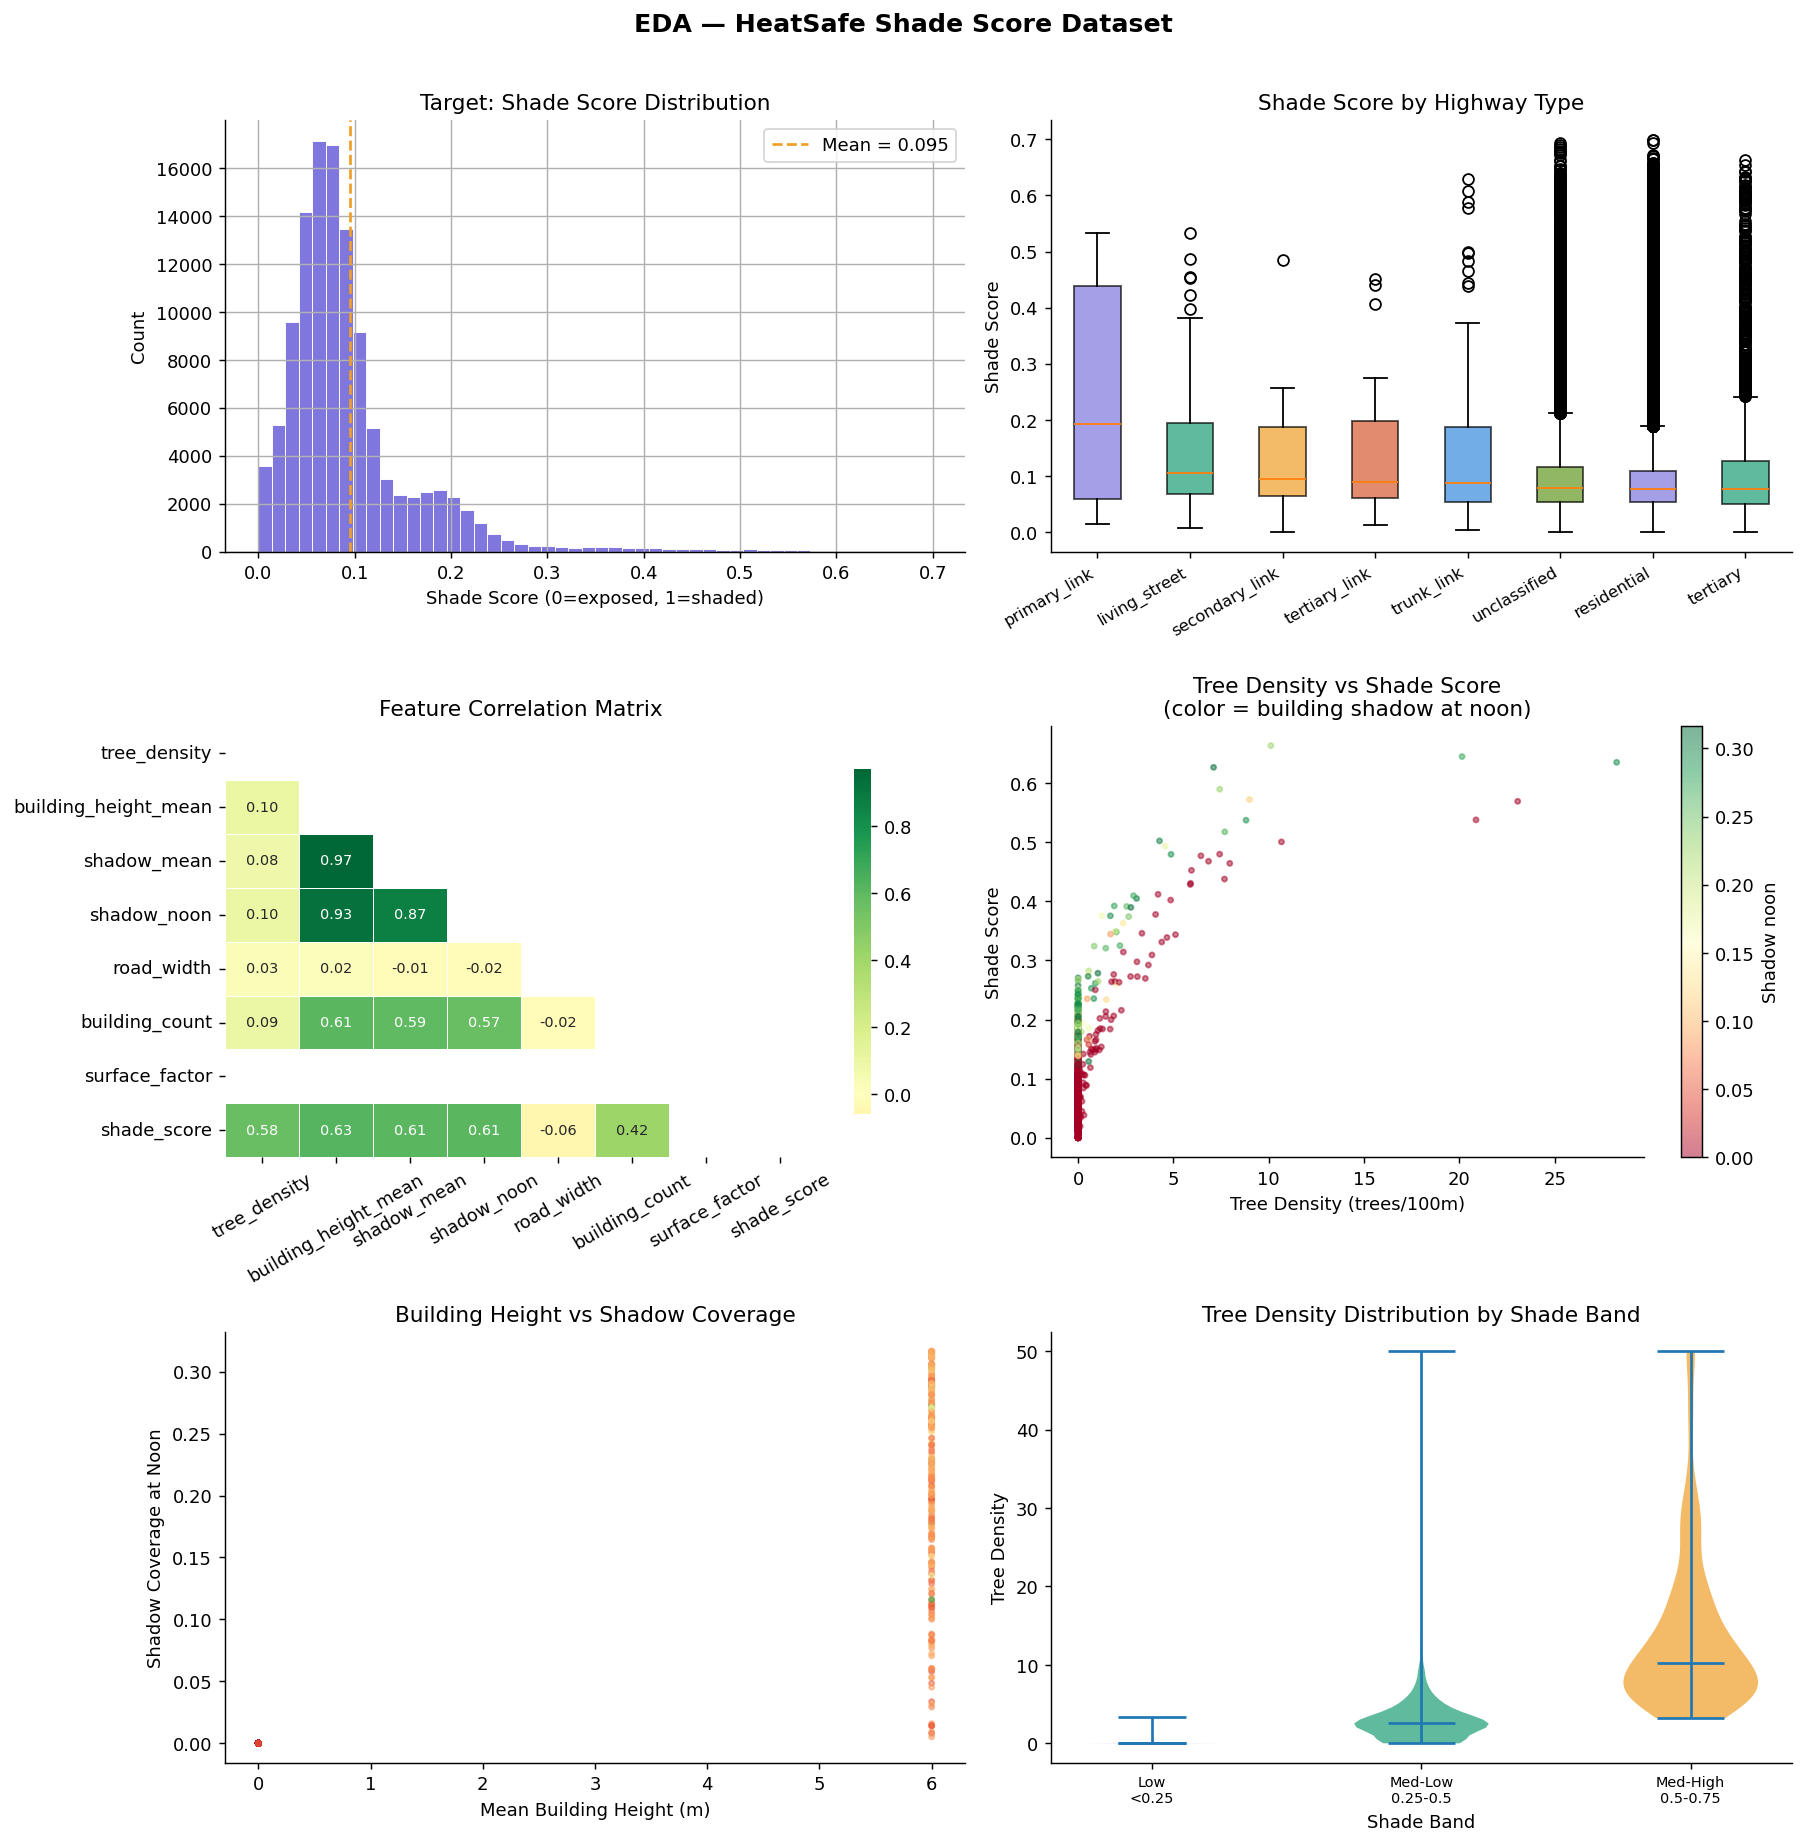

✅ EDA plots saved to artifacts/eda_plots.png


In [17]:
# ─────────────────────────────────────────────
# CELL 11 ▸ EXPLORATORY DATA ANALYSIS (EDA)
#           Detailed — 6 plots
# ─────────────────────────────────────────────
#  Ensure highway_str is in model_df
if 'highway_str' not in model_df.columns and 'highway' in model_df.columns:
    # If the highway column exists in model_df, create the string version here
    model_df['highway_str'] = model_df['highway'].apply(
        lambda x: x[0] if isinstance(x, list) else (x if pd.notna(x) else 'unclassified')
    )
elif 'highway_str' not in model_df.columns and 'df' in globals() and 'highway_str' in df.columns:
    # If it was created in df, copy it over
    model_df['highway_str'] = df['highway_str']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('EDA — HeatSafe Shade Score Dataset', fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Target Distribution ──
ax = axes[0, 0]
model_df[TARGET_COL].hist(bins=50, ax=ax, color=PALETTE[0], edgecolor='white', linewidth=0.5)
ax.axvline(model_df[TARGET_COL].mean(), color=PALETTE[2], linestyle='--', lw=1.5,
            label=f'Mean = {model_df[TARGET_COL].mean():.3f}')
ax.set_title('Target: Shade Score Distribution')
ax.set_xlabel('Shade Score (0=exposed, 1=shaded)')
ax.set_ylabel('Count')
ax.legend()

# ── Plot 2: Shade Score by Highway Type ──
ax = axes[0, 1]
ht_order = model_df.groupby('highway_str')[TARGET_COL].median().sort_values(ascending=False)
top_hts = ht_order.head(8).index.tolist()
shade_by_hw = [model_df.loc[model_df['highway_str']==ht, TARGET_COL].values for ht in top_hts]
bp = ax.boxplot(shade_by_hw, patch_artist=True, notch=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(PALETTE[i % len(PALETTE)])
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(top_hts)+1))
ax.set_xticklabels(top_hts, rotation=30, ha='right', fontsize=9)
ax.set_title('Shade Score by Highway Type')
ax.set_ylabel('Shade Score')

# ── Plot 3: Correlation Heatmap ──
ax = axes[1, 0]
corr_cols = ['tree_density', 'building_height_mean', 'shadow_mean', 'shadow_noon',
              'road_width', 'building_count', 'surface_factor', TARGET_COL]
corr = model_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

# ── Plot 4: Tree Density vs Shade Score ──
ax = axes[1, 1]
scatter_sample = model_df.sample(min(2000, len(model_df)), random_state=SEED)
sc = ax.scatter(scatter_sample['tree_density'], scatter_sample[TARGET_COL],
                c=scatter_sample['shadow_noon'], cmap='RdYlGn',
                alpha=0.5, s=8)
plt.colorbar(sc, ax=ax, label='Shadow noon')
ax.set_xlabel('Tree Density (trees/100m)')
ax.set_ylabel('Shade Score')
ax.set_title('Tree Density vs Shade Score\n(color = building shadow at noon)')

# ── Plot 5: Building Height vs Shadow Coverage ──
ax = axes[2, 0]
ax.scatter(scatter_sample['building_height_mean'], scatter_sample['shadow_noon'],
            c=scatter_sample[TARGET_COL], cmap='RdYlGn', alpha=0.5, s=8)
ax.set_xlabel('Mean Building Height (m)')
ax.set_ylabel('Shadow Coverage at Noon')
ax.set_title('Building Height vs Shadow Coverage')

# ── Plot 6: Feature Distribution Violin ──
# ── Plot 6: Feature Distribution Violin ──
ax = axes[2, 1]

# 1. Add include_lowest=True so exact 0.0 values are not dropped
model_df['shade_bin'] = pd.cut(model_df[TARGET_COL],
                               bins=[0, 0.25, 0.5, 0.75, 1.0],
                               labels=['Low\n<0.25','Med-Low\n0.25-0.5',
                                       'Med-High\n0.5-0.75','High\n>0.75'],
                               include_lowest=True)

# 2. Extract values
shade_bin_groups = [model_df.loc[model_df['shade_bin']==b, 'tree_density'].values
                    for b in model_df['shade_bin'].cat.categories]

# 3. Filter out empty arrays to prevent the matplotlib crash
valid_groups = [group for group in shade_bin_groups if len(group) > 0]
valid_labels = [b for b, group in zip(model_df['shade_bin'].cat.categories, shade_bin_groups) if len(group) > 0]

# 4. Only plot if we have valid data
if len(valid_groups) > 0:
    vp = ax.violinplot(valid_groups, showmedians=True)
    for i, body in enumerate(vp['bodies']):
        body.set_facecolor(PALETTE[i % len(PALETTE)])
        body.set_alpha(0.7)

    ax.set_xticks(range(1, len(valid_labels) + 1))
    ax.set_xticklabels(valid_labels, fontsize=8)
else:
    ax.text(0.5, 0.5, "No valid data for violin plot", ha='center', va='center')

ax.set_xlabel('Shade Band')
ax.set_ylabel('Tree Density')
ax.set_title('Tree Density Distribution by Shade Band')

plt.tight_layout()
plt.savefig(f"{CONFIG['artifact_dir']}eda_plots.png", dpi=130, bbox_inches='tight')
plt.show()
print(f"✅ EDA plots saved to {CONFIG['artifact_dir']}eda_plots.png")

In [19]:
# ─────────────────────────────────────────────
# CELL 12 ▸ EDA CONTINUED — Statistical Summary
# ─────────────────────────────────────────────
print('='*55)
print('DATASET SUMMARY')
print('='*55)
print(f'Total road segments  : {len(model_df):,}')
print(f'Feature columns      : {len(FEATURE_COLS)}')
print()

# Skewness check — high skew features need attention
print('SKEWNESS (|skew| > 1 = consider log transform):')
skew = model_df[FEATURE_COLS].skew().sort_values(ascending=False)
for feat, val in skew.items():
    flag = '⚠️ ' if abs(val) > 1 else '✅ '
    print(f'  {flag}{feat:35s}: {val:+.3f}')

print()
print('OUTLIER CHECK (% of values > 3σ from mean):')
for col in ['tree_density', 'building_height_mean', 'building_count', 'road_width']:
    mean, std = model_df[col].mean(), model_df[col].std()
    pct_out = (np.abs(model_df[col] - mean) > 3*std).mean() * 100
    flag = '⚠️ ' if pct_out > 5 else '✅ '
    print(f'  {flag}{col:35s}: {pct_out:.2f}% outliers')

print()
print('CORRELATION WITH TARGET (shade_score):')
# Drop NaNs before looping
target_corr = target_corr.dropna().abs().sort_values(ascending=False)

for feat, val in target_corr.items():
    bar = '█' * int(val * 20)
    print(f'  {feat:35s}: {val:.4f} {bar}')

DATASET SUMMARY
Total road segments  : 116,950
Feature columns      : 16

SKEWNESS (|skew| > 1 = consider log transform):
  ⚠️ length_m                           : +22.612
  ⚠️ tree_density                       : +17.936
  ⚠️ is_oneway                          : +7.619
  ⚠️ tree_count                         : +6.284
  ⚠️ building_count                     : +6.099
  ⚠️ road_width                         : +4.634
  ⚠️ shadow_min                         : +2.645
  ⚠️ highway_enc                        : +2.481
  ⚠️ shadow_noon                        : +2.410
  ⚠️ shadow_mean                        : +2.134
  ⚠️ shadow_peak                        : +2.077
  ⚠️ building_height_mean               : +1.999
  ✅ road_orientation_deg               : +0.011
  ✅ surface_enc                        : +0.000
  ✅ surface_factor                     : +0.000
  ✅ sun_elevation_noon                 : +0.000

OUTLIER CHECK (% of values > 3σ from mean):
  ✅ tree_density                       : 1.05% outl

In [20]:
# ─────────────────────────────────────────────
# CELL 13 ▸ DATA CLEANING & PREPROCESSING
# ─────────────────────────────────────────────

# 1. Log-transform right-skewed features
LOG_COLS = ['tree_count', 'tree_density', 'building_count', 'length_m']
for col in LOG_COLS:
    if col in model_df.columns:
        model_df[f'{col}_log'] = np.log1p(model_df[col])
        print(f'✅ log1p({col}) → {col}_log')

# 2. Clip extreme outliers (>99th percentile) for numerical stability
CLIP_COLS = ['building_height_mean', 'road_width', 'tree_density']
for col in CLIP_COLS:
    p99 = model_df[col].quantile(0.99)
    before = (model_df[col] > p99).sum()
    model_df[col] = model_df[col].clip(upper=p99)
    print(f'✅ Clipped {col} at p99={p99:.2f} — {before} values capped')

# 3. Drop low-quality rows
# Roads < 5m long are OSM artifacts, not real segments
before = len(model_df)
model_df = model_df[model_df['length_m'] >= 5].copy()
print(f'\n✅ Removed {before - len(model_df)} segments with length < 5m')

# 4. Drop shade_bin column (was for EDA only)
model_df.drop(columns=['shade_bin'], errors='ignore', inplace=True)

# Update feature list to include log-transformed versions
LOG_FEATURE_COLS = [f'{c}_log' for c in LOG_COLS if c in model_df.columns]
REMOVE_COLS = LOG_COLS  # remove originals since we have log versions

FINAL_FEATURES = [
    c for c in FEATURE_COLS
    if c not in REMOVE_COLS
] + LOG_FEATURE_COLS

print(f'\n📋 Final feature set ({len(FINAL_FEATURES)} features):')
for f in FINAL_FEATURES:
    print(f'   {f}')
print(f'\nClean dataset shape: {model_df.shape}')

✅ log1p(tree_count) → tree_count_log
✅ log1p(tree_density) → tree_density_log
✅ log1p(building_count) → building_count_log
✅ log1p(length_m) → length_m_log
✅ Clipped building_height_mean at p99=6.00 — 70 values capped
✅ Clipped road_width at p99=12.00 — 0 values capped
✅ Clipped tree_density at p99=4.56 — 1170 values capped

✅ Removed 761 segments with length < 5m

📋 Final feature set (16 features):
   road_width
   road_orientation_deg
   is_oneway
   highway_enc
   surface_enc
   surface_factor
   building_height_mean
   shadow_mean
   shadow_peak
   shadow_min
   shadow_noon
   sun_elevation_noon
   tree_count_log
   tree_density_log
   building_count_log
   length_m_log

Clean dataset shape: (116189, 22)


In [21]:
# ─────────────────────────────────────────────
# CELL 14 ▸ TRAIN / VALIDATION / TEST SPLIT
#           + FEATURE SCALING
# ─────────────────────────────────────────────

X = model_df[FINAL_FEATURES].values
y = model_df[TARGET_COL].values

# 70% train | 15% val | 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, shuffle=True
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED  # 0.176 * 0.85 ≈ 0.15
)

print(f'Split sizes:')
print(f'  Train : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val   : {len(X_val):,}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test  : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')

# RobustScaler — handles outliers better than StandardScaler
# (uses IQR instead of mean/std)
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Note: XGBoost is tree-based — scaling doesn't change its output.
# We scale anyway because:
#   1. FastAPI pipeline needs consistent preprocessing
#   2. If we add linear models later, they already work

print('\n✅ RobustScaler fitted on train set only (no data leakage)')
print('   (Scaler will be saved for API inference)')

Split sizes:
  Train : 81,378  (70.0%)
  Val   : 17,382  (15.0%)
  Test  : 17,429  (15.0%)

✅ RobustScaler fitted on train set only (no data leakage)
   (Scaler will be saved for API inference)


In [22]:
# ─────────────────────────────────────────────
# CELL 15 ▸ BASELINE MODEL
#           Simple XGBoost (default params)
# ─────────────────────────────────────────────

baseline_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=SEED,
    n_jobs=-1,
    objective='reg:squarederror',
    eval_metric='rmse',
)

baseline_model.fit(
    X_train_s, y_train,
    eval_set=[(X_val_s, y_val)],
    verbose=False
)

y_pred_base = baseline_model.predict(X_val_s)

def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f'{label}')
    print(f'  RMSE : {rmse:.5f}  (lower better)')
    print(f'  MAE  : {mae:.5f}  (lower better)')
    print(f'  R²   : {r2:.5f}  (higher better, 1.0=perfect)')
    print(f'  MAPE : {mape:.2f}%')
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

print('BASELINE MODEL (default params):')
base_metrics = evaluate(y_val, y_pred_base, label='Validation set')

# Overfit check
y_pred_train_base = baseline_model.predict(X_train_s)
train_r2 = r2_score(y_train, y_pred_train_base)
print(f'\n  Train R²  : {train_r2:.5f}')
print(f'  Val R²    : {base_metrics["r2"]:.5f}')
print(f'  Gap       : {train_r2 - base_metrics["r2"]:.5f} (< 0.05 is healthy)')

BASELINE MODEL (default params):
Validation set
  RMSE : 0.02973  (lower better)
  MAE  : 0.02376  (lower better)
  R²   : 0.84787  (higher better, 1.0=perfect)
  MAPE : 293510776369186.00%

  Train R²  : 0.83777
  Val R²    : 0.84787
  Gap       : -0.01010 (< 0.05 is healthy)


In [25]:
# ─────────────────────────────────────────────
# CELL 16 ▸ OPTUNA HYPERPARAMETER TUNING
#           Anti-overfitting measures built in:
#           • early_stopping_rounds
#           • min_child_weight
#           • subsample / colsample
#           • reg_alpha / reg_lambda
# ─────────────────────────────────────────────

def objective(trial):
    params = {
        # Tree structure — controls complexity
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 20),

        # Boosting — controls convergence
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 800),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),

        # Stochastic — prevents overfitting via sampling
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.4, 1.0),

        # Regularization — explicit overfitting control
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma'             : trial.suggest_float('gamma', 0, 5),

        # Fixed
        'objective'         : 'reg:squarederror',
        'eval_metric'       : 'rmse',
        'random_state'      : SEED,
        'n_jobs'            : -1,
        'tree_method'       : 'hist',   # faster on large datasets
    }

    # NEW CODE (Fixed)
    model = xgb.XGBRegressor(
        early_stopping_rounds=50
    )

    model.fit(
      X_train, y_train,
      eval_set=[(X_val, y_val)],
      verbose=False
    )

    preds = model.predict(X_val_s)
    return np.sqrt(mean_squared_error(y_val, preds))   # minimize RMSE


print(f'🔍 Running Optuna ({CONFIG["n_trials"]} trials)...')
print('   Each trial: full XGBoost fit with early stopping')
print('   This finds the best hyperparameters that minimize validation RMSE')
print()

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(objective, n_trials=CONFIG['n_trials'], show_progress_bar=True)

print(f'\n🏆 Best trial:')
print(f'   RMSE   : {study.best_value:.6f}')
print(f'   Params : ')
for k, v in study.best_params.items():
    print(f'     {k:30s}: {v}')

🔍 Running Optuna (60 trials)...
   Each trial: full XGBoost fit with early stopping
   This finds the best hyperparameters that minimize validation RMSE



  0%|          | 0/60 [00:00<?, ?it/s]


🏆 Best trial:
   RMSE   : 0.035735
   Params : 
     max_depth                     : 5
     min_child_weight              : 20
     n_estimators                  : 613
     learning_rate                 : 0.058006322999333615
     subsample                     : 0.5780093202212182
     colsample_bytree              : 0.49359671220172163
     colsample_bylevel             : 0.4348501673009197
     reg_alpha                     : 0.6245760287469893
     reg_lambda                    : 0.002570603566117598
     gamma                         : 3.540362888980227


In [26]:
# ─────────────────────────────────────────────
# CELL 17 ▸ TRAIN FINAL MODEL (best params)
#           + Cross-Validation
# ─────────────────────────────────────────────

best_params = {
    **study.best_params,
    'objective'  : 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': SEED,
    'n_jobs'     : -1,
    'tree_method': 'hist',
}

final_model = xgb.XGBRegressor(**best_params)

# Train on train+val combined (test set still untouched)
X_trainval = np.vstack([X_train_s, X_val_s])
y_trainval = np.concatenate([y_train, y_val])

final_model.fit(
    X_trainval, y_trainval,
    verbose=False
)

# 5-Fold Cross-Validation on train+val
print(f'Running {CONFIG["cv_folds"]}-fold cross-validation...')
kf = KFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=SEED)
cv_model = xgb.XGBRegressor(**best_params)

cv_rmse = cross_val_score(
    cv_model, X_trainval, y_trainval,
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
)
cv_r2 = cross_val_score(
    cv_model, X_trainval, y_trainval,
    cv=kf, scoring='r2', n_jobs=-1
)

print(f'\n📊 Cross-Validation Results ({CONFIG["cv_folds"]} folds):')
print(f'  CV RMSE : {(-cv_rmse).mean():.5f} ± {cv_rmse.std():.5f}')
print(f'  CV R²   : {cv_r2.mean():.5f} ± {cv_r2.std():.5f}')
print(f'\n  Low std dev = model is stable across data splits ✅')

Running 5-fold cross-validation...

📊 Cross-Validation Results (5 folds):
  CV RMSE : 0.03326 ± 0.00026
  CV R²   : 0.79817 ± 0.00353

  Low std dev = model is stable across data splits ✅


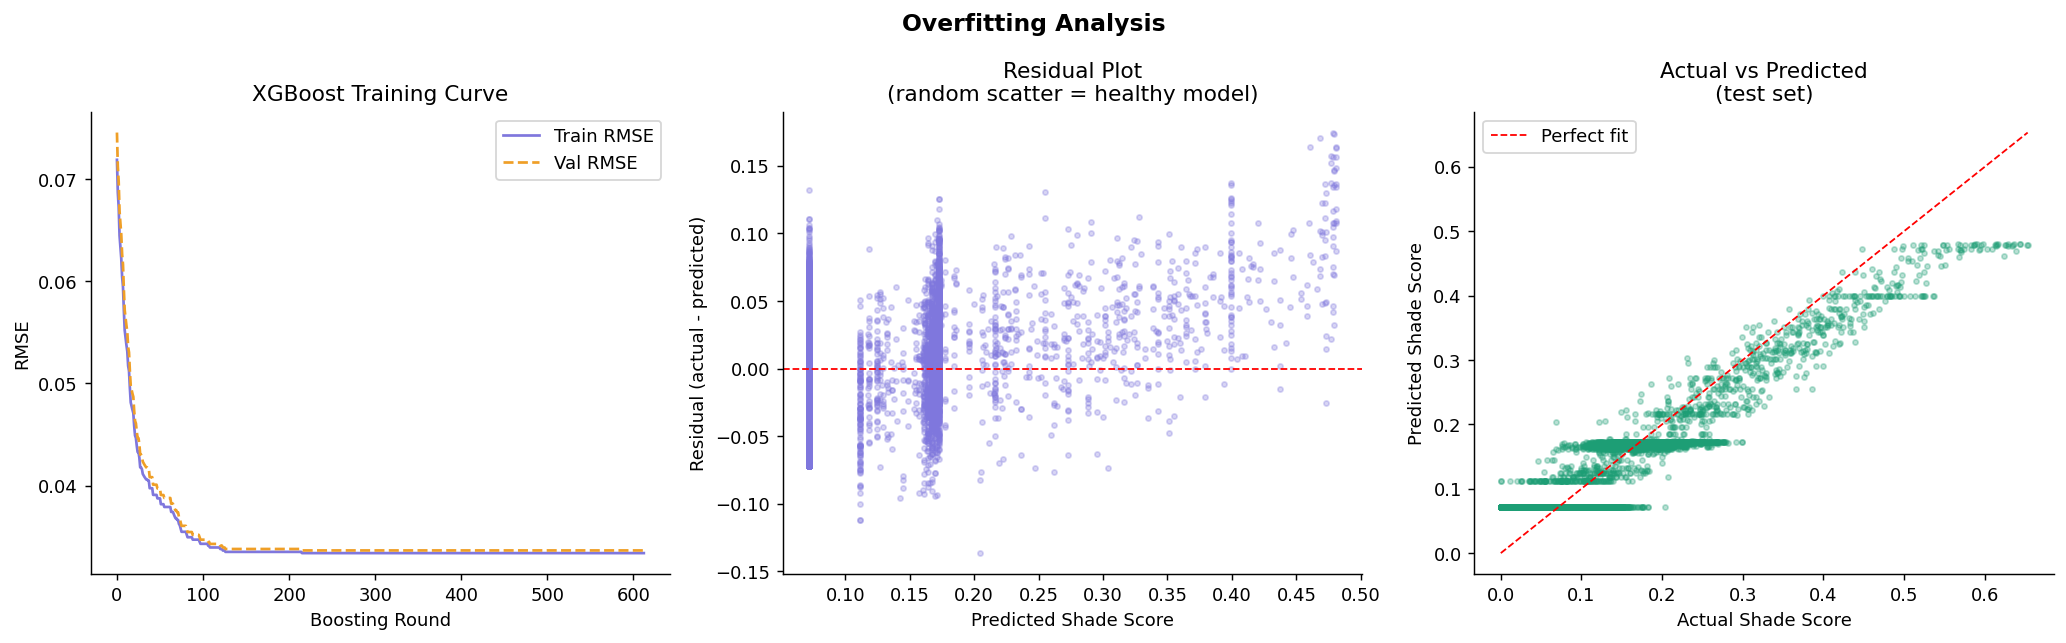


🔍 FINAL MODEL EVALUATION:
Train set
  RMSE : 0.03279  (lower better)
  MAE  : 0.02589  (lower better)
  R²   : 0.80121  (higher better, 1.0=perfect)
  MAPE : 348700215509821.50%

Test set (held-out)
  RMSE : 0.03259  (lower better)
  MAE  : 0.02572  (lower better)
  R²   : 0.80373  (higher better, 1.0=perfect)
  MAPE : 356288758759540.12%

Train-Test R² gap: -0.0025 ✅ No overfitting


In [27]:
# ─────────────────────────────────────────────
# CELL 18 ▸ OVERFITTING ANALYSIS
#           Learning Curves + Train vs Val
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Overfitting Analysis', fontsize=13, fontweight='bold')

# ── Plot 1: XGBoost training history ──
ax = axes[0]
# Refit with eval set to get training curve
temp_model = xgb.XGBRegressor(**best_params)
temp_model.fit(
    X_train_s, y_train,
    eval_set=[(X_train_s, y_train), (X_val_s, y_val)],
    verbose=False
)
results = temp_model.evals_result()
n_rounds = len(results['validation_0']['rmse'])
ax.plot(results['validation_0']['rmse'], label='Train RMSE', color=PALETTE[0])
ax.plot(results['validation_1']['rmse'], label='Val RMSE',   color=PALETTE[2], linestyle='--')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost Training Curve')
ax.legend()

# ── Plot 2: Prediction residuals ──
ax = axes[1]
y_pred_test = final_model.predict(X_test_s)
residuals = y_test - y_pred_test
ax.scatter(y_pred_test, residuals, alpha=0.3, s=8, color=PALETTE[0])
ax.axhline(0, color='red', linestyle='--', lw=1)
ax.set_xlabel('Predicted Shade Score')
ax.set_ylabel('Residual (actual - predicted)')
ax.set_title('Residual Plot\n(random scatter = healthy model)')

# ── Plot 3: Predicted vs Actual ──
ax = axes[2]
ax.scatter(y_test, y_pred_test, alpha=0.3, s=8, color=PALETTE[1])
diag_min = min(y_test.min(), y_pred_test.min())
diag_max = max(y_test.max(), y_pred_test.max())
ax.plot([diag_min, diag_max], [diag_min, diag_max], 'r--', lw=1, label='Perfect fit')
ax.set_xlabel('Actual Shade Score')
ax.set_ylabel('Predicted Shade Score')
ax.set_title('Actual vs Predicted\n(test set)')
ax.legend()

plt.tight_layout()
plt.savefig(f"{CONFIG['artifact_dir']}overfitting_analysis.png", dpi=130, bbox_inches='tight')
plt.show()

print('\n🔍 FINAL MODEL EVALUATION:')
train_metrics = evaluate(y_train, final_model.predict(X_train_s), 'Train set')
print()
test_metrics = evaluate(y_test, y_pred_test, 'Test set (held-out)')
print()
gap = train_metrics['r2'] - test_metrics['r2']
print(f'Train-Test R² gap: {gap:.4f}', '✅ No overfitting' if gap < 0.05 else '⚠️ Slight overfitting — consider more regularization')

🧠 Computing SHAP values (may take ~1 min)...


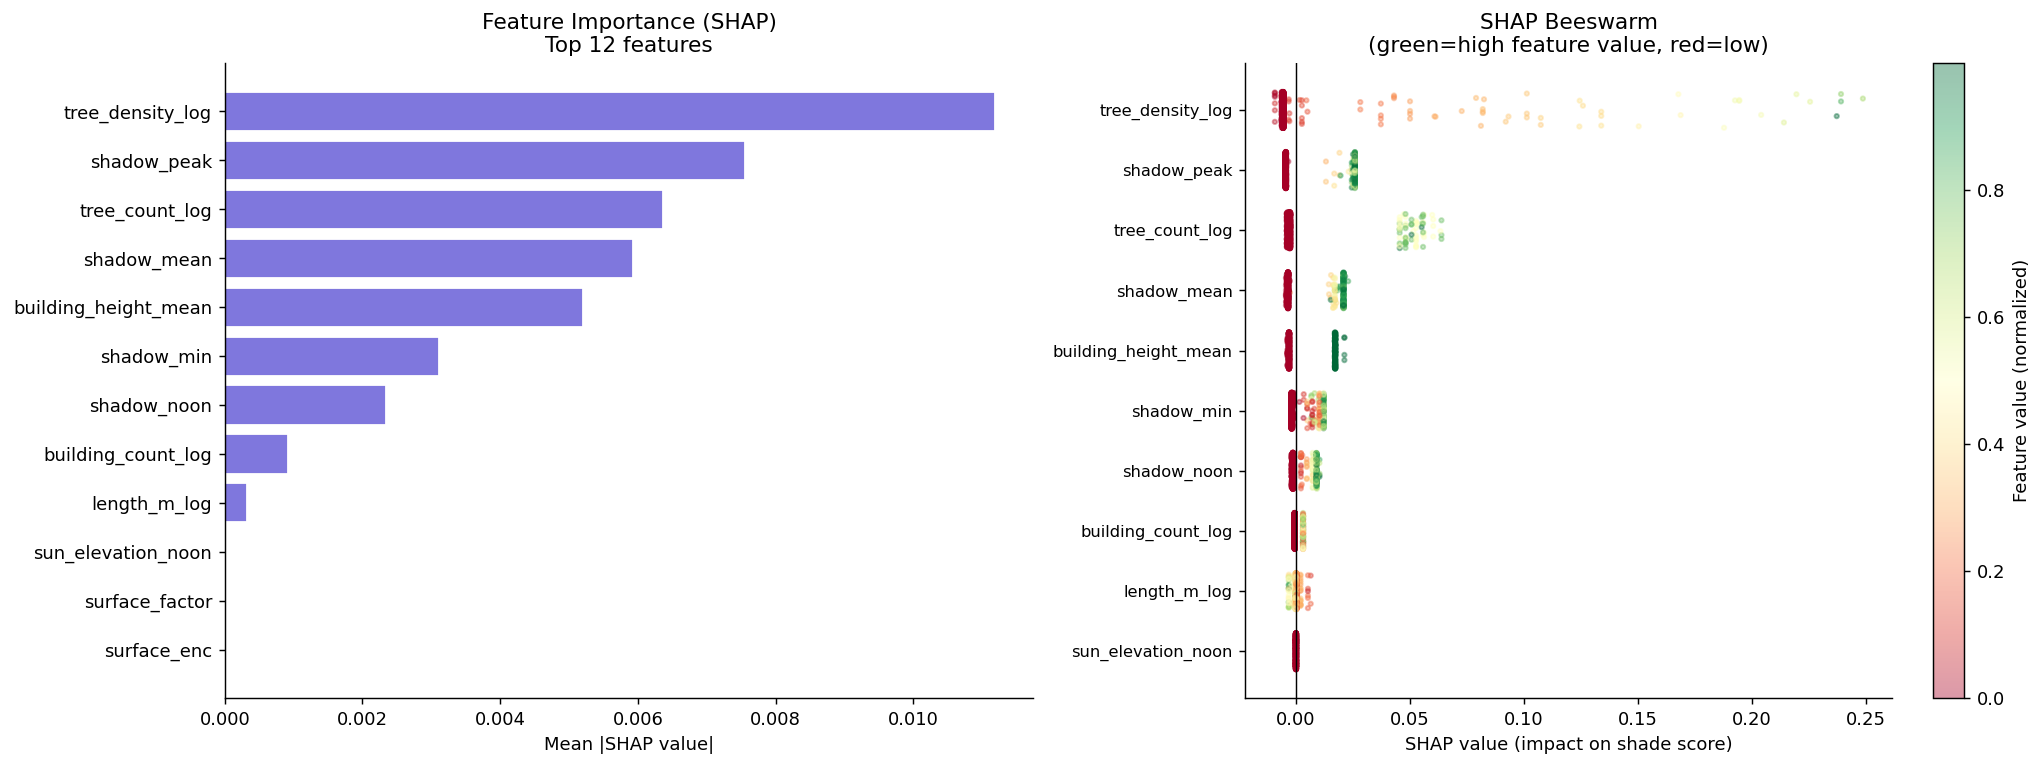


📋 SHAP Feature Ranking (for your report):
  # 1  tree_density_log                   : 0.01118
  # 2  shadow_peak                        : 0.00755
  # 3  tree_count_log                     : 0.00637
  # 4  shadow_mean                        : 0.00593
  # 5  building_height_mean               : 0.00521
  # 6  shadow_min                         : 0.00312
  # 7  shadow_noon                        : 0.00234
  # 8  building_count_log                 : 0.00092
  # 9  length_m_log                       : 0.00033
  #10  sun_elevation_noon                 : 0.00000
  #11  surface_factor                     : 0.00000
  #12  surface_enc                        : 0.00000
  #13  highway_enc                        : 0.00000
  #14  is_oneway                          : 0.00000
  #15  road_orientation_deg               : 0.00000
  #16  road_width                         : 0.00000


In [28]:
# ─────────────────────────────────────────────
# CELL 19 ▸ SHAP FEATURE IMPORTANCE
#           Explainability for judges + devs
# ─────────────────────────────────────────────

print('🧠 Computing SHAP values (may take ~1 min)...')

explainer = shap.TreeExplainer(final_model)

# Compute SHAP on test set sample (max 1000 for speed)
n_shap = min(1000, len(X_test_s))
shap_sample = X_test_s[:n_shap]
shap_values = explainer.shap_values(shap_sample)

# Feature names for plots
feature_names = FINAL_FEATURES

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── SHAP bar plot (mean |SHAP|) ──
ax = axes[0]
mean_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[::-1]
top_n = 12
bars = ax.barh(
    [feature_names[i] for i in sorted_idx[:top_n]][::-1],
    mean_shap[sorted_idx[:top_n]][::-1],
    color=PALETTE[0], edgecolor='white'
)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance (SHAP)\nTop 12 features')

# ── SHAP beeswarm (summary plot via matplotlib) ──
ax = axes[1]
top_feat_idx = sorted_idx[:10]
for i, fidx in enumerate(top_feat_idx[::-1]):
    shap_col = shap_values[:, fidx]
    feat_col = shap_sample[:, fidx]
    norm_feat = (feat_col - feat_col.min()) / (feat_col.max() - feat_col.min() + 1e-9)
    jitter = np.random.uniform(-0.3, 0.3, len(shap_col))
    sc = ax.scatter(shap_col, np.full_like(shap_col, i) + jitter,
                     c=norm_feat, cmap='RdYlGn', alpha=0.4, s=6)

ax.set_yticks(range(10))
ax.set_yticklabels([feature_names[i] for i in top_feat_idx[::-1]], fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('SHAP value (impact on shade score)')
ax.set_title('SHAP Beeswarm\n(green=high feature value, red=low)')
plt.colorbar(sc, ax=ax, label='Feature value (normalized)')

plt.tight_layout()
plt.savefig(f"{CONFIG['artifact_dir']}shap_analysis.png", dpi=130, bbox_inches='tight')
plt.show()

print('\n📋 SHAP Feature Ranking (for your report):')
for rank, idx in enumerate(sorted_idx[:len(feature_names)]):
    print(f'  #{rank+1:2d}  {feature_names[idx]:35s}: {mean_shap[idx]:.5f}')

In [29]:
# ─────────────────────────────────────────────
# CELL 20 ▸ SAVE ALL ARTIFACTS
#           Everything the web team needs
# ─────────────────────────────────────────────

ARTIFACT = CONFIG['artifact_dir']

# 1. Model
model_path = f'{ARTIFACT}shade_model.joblib'
joblib.dump(final_model, model_path)
print(f'✅ Model saved       : {model_path}')

# 2. Scaler
scaler_path = f'{ARTIFACT}scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f'✅ Scaler saved      : {scaler_path}')

# 3. Label encoders
encoders = {
    'highway': le_highway,
    'surface': le_surface
}
encoders_path = f'{ARTIFACT}label_encoders.joblib'
joblib.dump(encoders, encoders_path)
print(f'✅ Encoders saved    : {encoders_path}')

# 4. Feature list + metadata
metadata = {
    'features'           : FINAL_FEATURES,
    'target'             : TARGET_COL,
    'highway_classes'    : le_highway.classes_.tolist(),
    'surface_classes'    : le_surface.classes_.tolist(),
    'highway_width_proxy': HIGHWAY_WIDTH_PROXY,
    'surface_shade_factor': SURFACE_SHADE_FACTOR,
    'log_cols'           : LOG_COLS,
    'clip_cols'          : CLIP_COLS,
    'city'               : CONFIG['city'],
    'lat'                : CONFIG['lat'],
    'lon'                : CONFIG['lon'],
    'timezone'           : CONFIG['timezone'],
    'tree_radius'        : CONFIG['tree_radius'],
    'building_radius'    : CONFIG['building_radius'],
    'best_params'        : study.best_params,
    'test_metrics'       : test_metrics,
    'cv_rmse_mean'       : float((-cv_rmse).mean()),
    'cv_r2_mean'         : float(cv_r2.mean()),
    'shap_feature_ranking': [
        {'rank': rank+1, 'feature': FINAL_FEATURES[idx], 'mean_shap': float(mean_shap[idx])}
        for rank, idx in enumerate(sorted_idx)
    ]
}

meta_path = f'{ARTIFACT}model_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'✅ Metadata saved    : {meta_path}')

# 5. Sample prediction to verify everything works end-to-end
sample_row = X_test_s[0:1]
sample_pred = final_model.predict(sample_row)[0]
print(f'\n🧪 Sanity check — one prediction: {sample_pred:.4f}  (expect 0.0–1.0)')

print(f'\n📦 All artifacts saved to: {ARTIFACT}')
print('   Hand these 4 files to your web backend team:')
print(f'   • shade_model.joblib    (XGBoost model)')
print(f'   • scaler.joblib         (RobustScaler)')
print(f'   • label_encoders.joblib (highway + surface encoders)')
print(f'   • model_metadata.json   (feature list + config)')

✅ Model saved       : artifacts/shade_model.joblib
✅ Scaler saved      : artifacts/scaler.joblib
✅ Encoders saved    : artifacts/label_encoders.joblib
✅ Metadata saved    : artifacts/model_metadata.json

🧪 Sanity check — one prediction: 0.0718  (expect 0.0–1.0)

📦 All artifacts saved to: artifacts/
   Hand these 4 files to your web backend team:
   • shade_model.joblib    (XGBoost model)
   • scaler.joblib         (RobustScaler)
   • label_encoders.joblib (highway + surface encoders)
   • model_metadata.json   (feature list + config)


---
## ✅ What was built & handed off

| Artifact | Purpose | Consumer |
|---|---|---|
| `artifacts/shade_model.joblib` | Trained XGBoost model | Backend/API |
| `artifacts/scaler.joblib` | RobustScaler (fit on train only) | Backend/API |
| `artifacts/label_encoders.joblib` | highway + surface encoders | Backend/API |
| `artifacts/model_metadata.json` | Features, config, metrics, SHAP ranking | Backend + Judges |
| `artifacts/eda_plots.png` | EDA visualizations | Hackathon presentation |
| `artifacts/shap_analysis.png` | Feature importance | Hackathon presentation |
| `app.py` | FastAPI serving all 3 above | Web frontend team |

## Anti-overfitting Measures Applied
- `early_stopping_rounds=30` in Optuna trials
- `min_child_weight`, `subsample`, `colsample_bytree` tuned by Optuna
- `reg_alpha` + `reg_lambda` L1/L2 regularization
- `gamma` (min split loss)
- 5-fold cross-validation to verify generalization
- RobustScaler fit **only on train set** (no leakage)
- Held-out test set **never seen during tuning**